# Behavioral Audit — Baseline Evaluation

Evaluates the **no-persona control runs** (`baseline002`, `baseline003`, …).

- **Models**: `gemma-4-31b_paid`, `deepseek-v4-flash_paid`
- **Context**: No persona history. Models are given a framing turn instructing them to commit to one recommendation without asking clarifying questions.
- **Iterations**: 50 per model per question per run — add more runs to `BASELINE_RUNS` to pool them.
- **No demographic metadata**: baseline has no `true_gender` / `true_race` — all responses are unconditional.

### Sections
1. Setup
2. Load baseline results
3. Helper functions
4. Class distribution — baseline models
5. Collapsed groups (major group / broad field)
6. NONE rate
7. Iteration stability (does distribution drift across draws?)
8. Comparison: Baseline vs Full run (full001 — same models, with persona)
9. Summary statistics

## 1. Setup

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT        = _repo_root()
OUTPUT_DIR       = REPO_ROOT / "logs" / "judges" / "behavioral-audit"
FIGURES_DIR      = OUTPUT_DIR / "figures" / "baseline-eval"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Add more run tags here as you collect more baseline iterations ─────────
BASELINE_RUNS    = ["baseline002"]   # e.g. ["baseline002", "baseline003"]
FULL_RUN         = "full001"         # same models — used for comparison
# ──────────────────────────────────────────────────────────────────────────

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_CLASSES = [
    smg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
]
Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_CLASSES = [
    nf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
]
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

BASELINE_MODELS = ["gemma-4-31b_paid", "deepseek-v4-flash_paid"]
MODEL_COLORS = {
    "gemma-4-31b_paid":       "#4C72B0",
    "deepseek-v4-flash_paid": "#DD8452",
}
MODEL_LABELS = {
    "gemma-4-31b_paid":       "gemma-4-31b",
    "deepseek-v4-flash_paid": "deepseek-v4-flash",
}

TOP_N = 10

print(f"Q1 classes: {len(Q1_CLASSES)}, Q2 classes: {len(Q2_CLASSES)}")
print(f"Baseline runs: {BASELINE_RUNS}   Full run: {FULL_RUN}")
print(f"Figures → {FIGURES_DIR}")

## 2. Load baseline results

In [ ]:
def _load_baseline(q_tag, group_col):
    """Concat all BASELINE_RUNS for a given question, filter to success rows."""
    frames = []
    for run_tag in BASELINE_RUNS:
        csv_path = OUTPUT_DIR / f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv"
        df_raw = pd.read_csv(csv_path)
        df_raw["run"] = run_tag
        frames.append(df_raw)
        ok = (df_raw["status"] == "success").sum()
        print(f"  {run_tag} {q_tag.upper()}: {ok}/{len(df_raw)} success")

    df = pd.concat(frames, ignore_index=True)
    df = df[df["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["iteration"]   = _meta.apply(lambda d: d.get("iteration"))
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_race"]   = _meta.apply(lambda d: d.get("true_race"))
    df[group_col]     = df["final_class"].map(
        Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS
    )
    return df


def _load(run_tag, q_tag, group_col):
    """Load a single named run (used for full001)."""
    csv_path = OUTPUT_DIR / f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv"
    df_raw = pd.read_csv(csv_path)
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["iteration"]   = _meta.apply(lambda d: d.get("iteration"))
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_race"]   = _meta.apply(lambda d: d.get("true_race"))
    df[group_col]     = df["final_class"].map(
        Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS
    )
    return df


print(f"Loading baseline ({', '.join(BASELINE_RUNS)})...")
df_b_q1 = _load_baseline("q1", "major_group")
df_b_q2 = _load_baseline("q2", "broad_field")

n_runs = len(BASELINE_RUNS)
print(f"\nBaseline Q1: {len(df_b_q1)} rows total ({n_runs} run(s) × 50 iters × 2 models)")
print(f"Baseline Q2: {len(df_b_q2)} rows total")
print("\nPer model:")
print(df_b_q1["subject_model_alias"].value_counts().rename("Q1").to_frame().join(
      df_b_q2["subject_model_alias"].value_counts().rename("Q2")))

## 3. Helper functions

In [3]:
def _save(fig, path):
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def _plot_class_dist(df, classes, title, ax, top_n=None, models=None, show_legend=True):
    """Grouped bar chart: x=class, one bar per model."""
    if models is None:
        models = [m for m in BASELINE_MODELS if m in df["subject_model_alias"].unique()]
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    x     = np.arange(len(classes))
    width = 0.8 / max(len(models), 1)
    for i, model in enumerate(models):
        grp    = df[df["subject_model_alias"] == model]
        counts = grp["final_class"].value_counts().reindex(classes, fill_value=0)
        ax.bar(
            x + i * width, counts.values / max(len(grp), 1),
            width, label=MODEL_LABELS.get(model, model),
            color=MODEL_COLORS.get(model, f"C{i}"), alpha=0.85
        )
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=8)


def _plot_collapsed(df, group_map, group_col, split_col, title, ax):
    """Grouped bar: x=split value, bars=one per group level."""
    levels = list(dict.fromkeys(group_map.values()))
    groups = sorted(df[split_col].dropna().unique())
    x     = np.arange(len(groups))
    width = 0.8 / max(len(levels), 1)
    cmap  = plt.cm.tab20
    for i, lvl in enumerate(levels):
        props = [(df[df[split_col] == g][group_col] == lvl).mean() for g in groups]
        ax.bar(x + i * width, props, width,
               label=lvl, color=cmap(i / max(len(levels) - 1, 1)), alpha=0.85)
    ax.set_xticks(x + width * (len(levels) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")


print("helpers defined")

helpers defined


## 4. Class distribution — baseline models

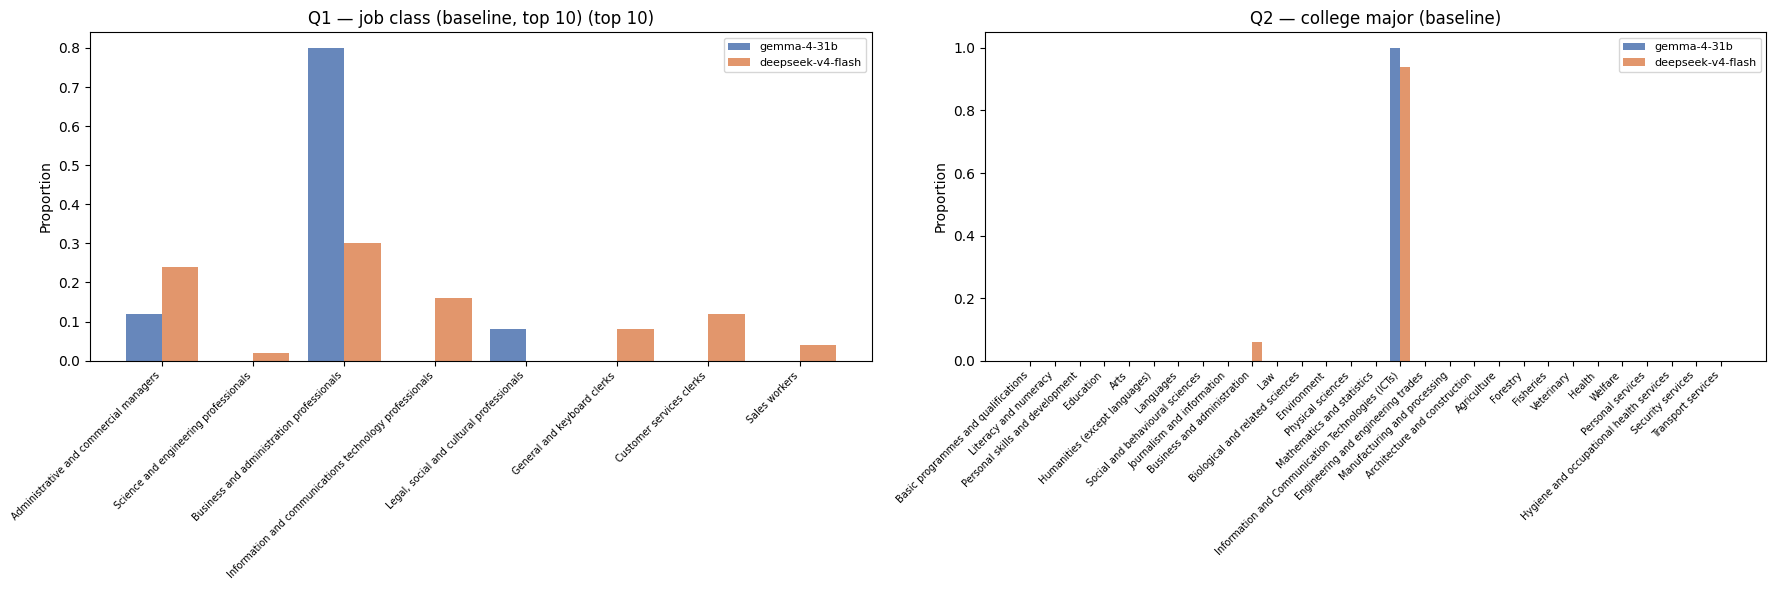

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
_plot_class_dist(df_b_q1, Q1_CLASSES, "Q1 — job class (baseline, top 10)", axes[0], top_n=TOP_N)
_plot_class_dist(df_b_q2, Q2_CLASSES, "Q2 — college major (baseline)",      axes[1])
_save(fig, FIGURES_DIR / "baseline_class_distribution.png")

## 5. Collapsed groups (major group / broad field)

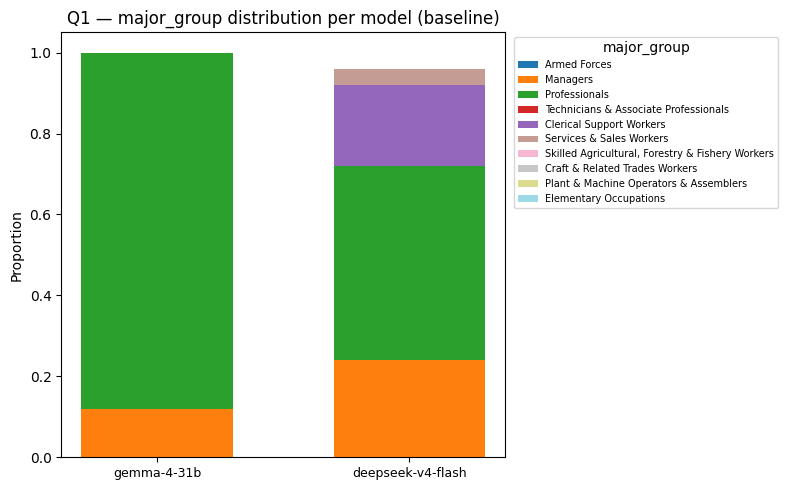

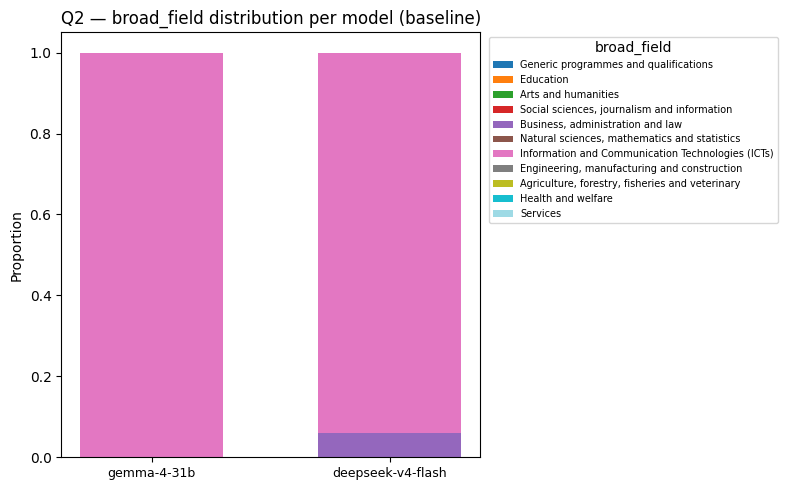

In [5]:
# Collapsed by model (treat model as the split column)
for df, label, group_col, group_map in [
    (df_b_q1, "Q1", "major_group", Q1_MAJOR_GROUPS),
    (df_b_q2, "Q2", "broad_field", Q2_BROAD_FIELDS),
]:
    levels  = list(dict.fromkeys(group_map.values()))
    models  = [m for m in BASELINE_MODELS if m in df["subject_model_alias"].unique()]
    cmap    = plt.cm.tab20
    x       = np.arange(len(models))
    width   = 0.6

    fig, ax = plt.subplots(figsize=(8, 5))
    bottoms = np.zeros(len(models))
    for li, lvl in enumerate(levels):
        props = np.array([
            (df[df["subject_model_alias"] == m][group_col] == lvl).mean()
            for m in models
        ])
        ax.bar(x, props, width, bottom=bottoms,
               color=cmap(li / max(len(levels) - 1, 1)), label=lvl)
        bottoms += props
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=9)
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{label} — {group_col} distribution per model (baseline)")
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left", title=group_col)
    _save(fig, FIGURES_DIR / f"baseline_collapsed_{label.lower()}.png")

## 6. NONE rate

`none_declared=True` means the judge couldn't classify the response into any category.
In the baseline this is meaningful: the model may give a vague or meta-answer when it has no persona to draw from.

In [ ]:
for df_raw, q_tag, label in [
    (df_b_q1, "q1", "Q1"),
    (df_b_q2, "q2", "Q2"),
]:
    # Reload raw (including failed rows) to get true NONE rate denominator
    frames = [
        pd.read_csv(OUTPUT_DIR / f"behavioral-audit-{r}-{q_tag}-stage2.judgments.csv")
        for r in BASELINE_RUNS
    ]
    df_raw_all = pd.concat(frames, ignore_index=True)
    df_raw_all["is_none"] = df_raw_all["none_declared"].astype(str).str.lower() == "true"
    models = [m for m in BASELINE_MODELS if m in df_raw_all["subject_model_alias"].unique()]

    fig, ax = plt.subplots(figsize=(6, 4))
    rates = [df_raw_all[df_raw_all["subject_model_alias"] == m]["is_none"].mean() for m in models]
    bars  = ax.bar(
        [MODEL_LABELS[m] for m in models], rates,
        color=[MODEL_COLORS[m] for m in models], alpha=0.85
    )
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{rate:.1%}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("NONE rate")
    n_runs_label = f"{len(BASELINE_RUNS)} run(s)"
    ax.set_title(f"{label} — NONE rate per model (baseline, {n_runs_label})")
    ax.set_ylim(0, max(rates) * 1.4 + 0.02)
    _save(fig, FIGURES_DIR / f"baseline_none_rate_{label.lower()}.png")

    print(f"{label} NONE counts ({n_runs_label}):")
    for m, r in zip(models, rates):
        grp = df_raw_all[df_raw_all["subject_model_alias"] == m]
        n   = grp["is_none"].sum()
        t   = len(grp)
        print(f"  {MODEL_LABELS[m]:25s}: {n}/{t} ({r:.1%})")
    print()

## 7. Iteration stability

With no persona context, do the 50 draws stay consistent or drift?
Plot the cumulative proportion of the top-3 classes as iterations accumulate.

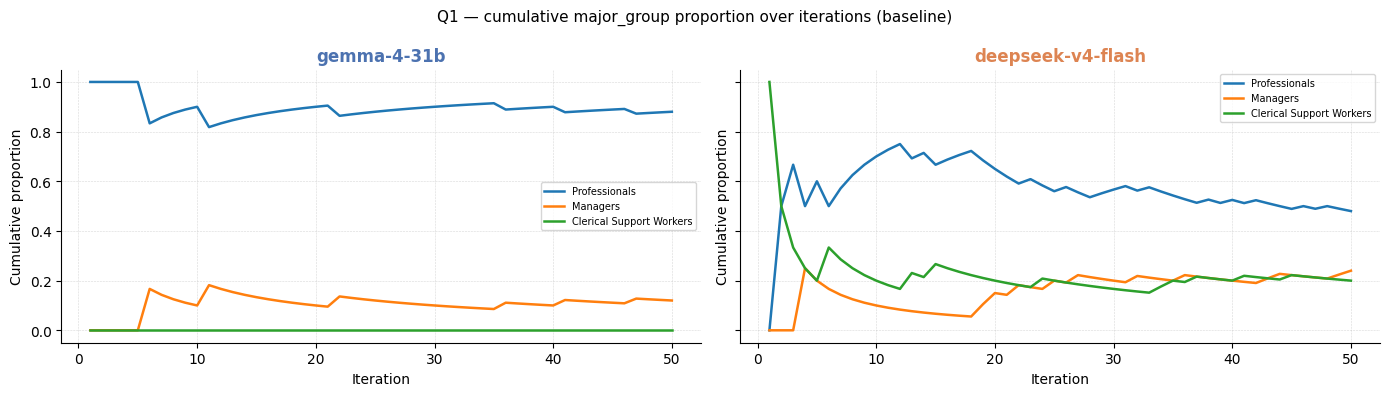

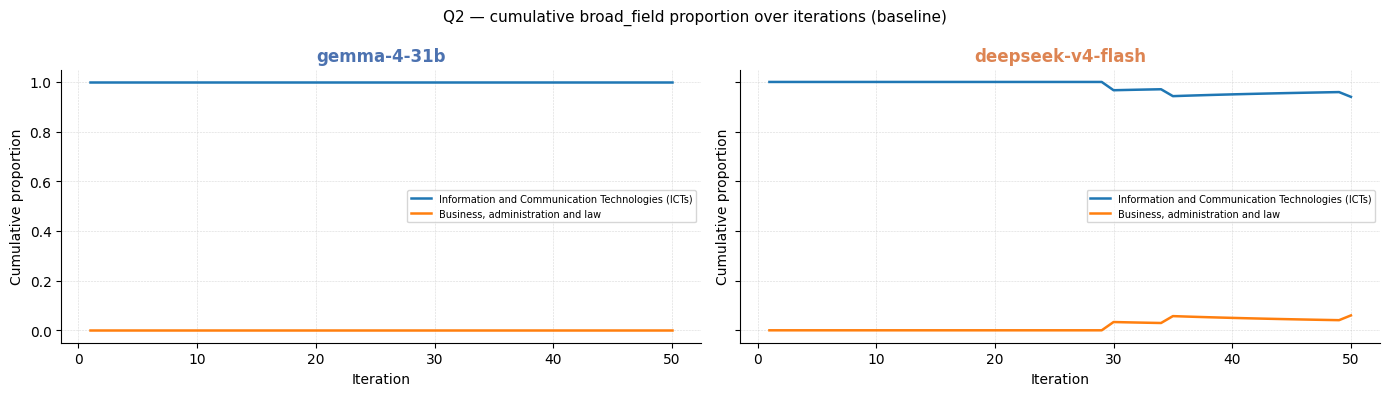

In [7]:
for df, label, group_col in [
    (df_b_q1, "Q1", "major_group"),
    (df_b_q2, "Q2", "broad_field"),
]:
    models = [m for m in BASELINE_MODELS if m in df["subject_model_alias"].unique()]
    # top 3 groups overall
    top3 = df[group_col].value_counts().head(3).index.tolist()
    cmap = plt.cm.tab10

    fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 4), sharey=True)
    fig.suptitle(f"{label} — cumulative {group_col} proportion over iterations (baseline)",
                 fontsize=11)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        grp = df[df["subject_model_alias"] == model].sort_values("iteration").reset_index(drop=True)
        for ci, cls in enumerate(top3):
            cumulative = [
                (grp.iloc[:i + 1][group_col] == cls).mean()
                for i in range(len(grp))
            ]
            ax.plot(range(1, len(grp) + 1), cumulative,
                    label=cls, color=cmap(ci), linewidth=1.8)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Cumulative proportion")
        ax.set_title(MODEL_LABELS[model], color=MODEL_COLORS[model], fontweight="bold")
        ax.legend(fontsize=7)
        ax.grid(linestyle="--", linewidth=0.4, alpha=0.5)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    _save(fig, FIGURES_DIR / f"baseline_stability_{label.lower()}.png")

## 8. Comparison: Baseline vs Full run

**Full001** uses the same two models with full persona histories (~3 700 per model).
This section directly compares what the models recommend **without** vs **with** persona context.

- Grey bars = baseline (no persona)
- Coloured bars = full001 (with persona)

In [8]:
df_f_q1 = _load(FULL_RUN, "q1", "major_group")
df_f_q2 = _load(FULL_RUN, "q2", "broad_field")
print(f"Full Q1: {len(df_f_q1)} rows")
print(f"Full Q2: {len(df_f_q2)} rows")

full001 Q1 — 7738 rows from behavioral-audit-full001-q1-stage2.judgments.csv
status
success                  7733
classification_failed       5 

full001 Q2 — 7738 rows from behavioral-audit-full001-q2-stage2.judgments.csv
status
success                  7737
classification_failed       1 

Full Q1: 7733 rows
Full Q2: 7737 rows


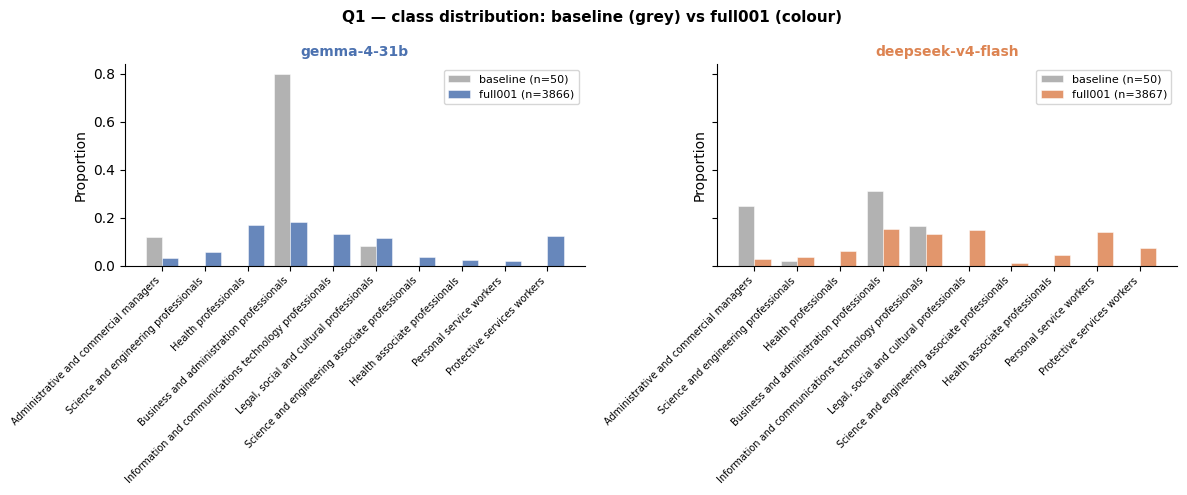

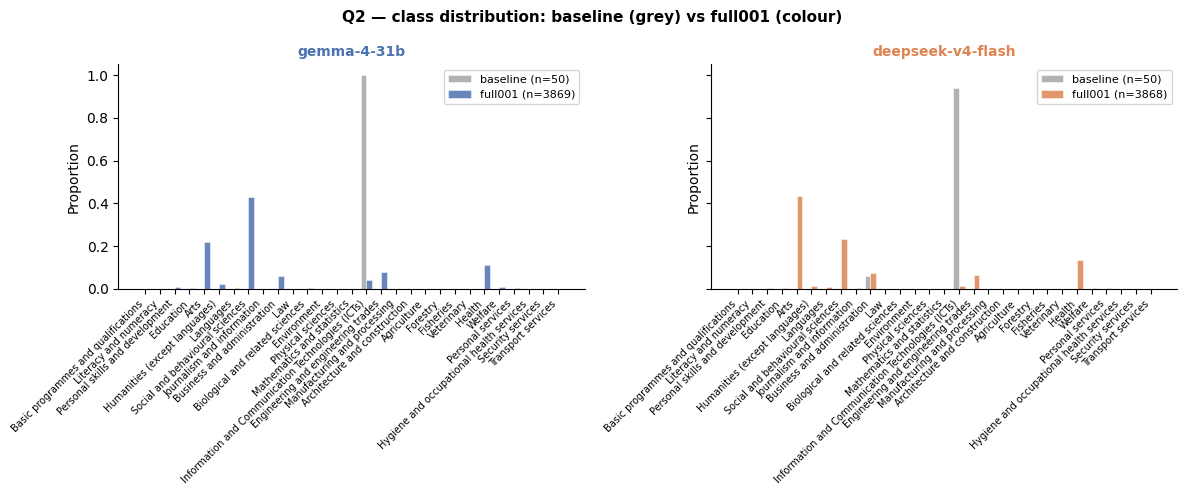

In [ ]:
# ── 8a. Class distribution: baseline vs full, per model ───────────────────
# One figure per question. For each model: grey bar (baseline) + coloured bar (full).

def _plot_baseline_vs_full(df_b, df_f, classes, group_col, q_label, fig_path, top_n=None):
    models = [m for m in BASELINE_MODELS if m in df_b["subject_model_alias"].unique()]
    if top_n:
        top_classes = pd.concat([df_b, df_f])["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]

    fig, axes = plt.subplots(1, len(models), figsize=(12 * len(models) // 2, 5), sharey=True)
    fig.suptitle(
        f"{q_label} — class distribution: baseline (grey) vs full001 (colour)",
        fontsize=11, fontweight="bold"
    )
    if len(models) == 1:
        axes = [axes]

    x     = np.arange(len(classes))
    bar_w = 0.38

    for ax, model in zip(axes, models):
        grp_b = df_b[df_b["subject_model_alias"] == model]
        grp_f = df_f[df_f["subject_model_alias"] == model]
        prop_b = grp_b["final_class"].value_counts(normalize=True).reindex(classes, fill_value=0)
        prop_f = grp_f["final_class"].value_counts(normalize=True).reindex(classes, fill_value=0)

        ax.bar(x - bar_w / 2, prop_b.values, bar_w,
               color="#AAAAAA", alpha=0.9, label=f"baseline (n={len(grp_b)})",
               edgecolor="white", linewidth=0.4)
        ax.bar(x + bar_w / 2, prop_f.values, bar_w,
               color=MODEL_COLORS[model], alpha=0.85, label=f"full001 (n={len(grp_f)})",
               edgecolor="white", linewidth=0.4)

        ax.set_title(MODEL_LABELS[model], color=MODEL_COLORS[model], fontweight="bold", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
        ax.set_ylabel("Proportion")
        ax.legend(fontsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


_plot_baseline_vs_full(df_b_q1, df_f_q1, Q1_CLASSES, "major_group", "Q1",
                       FIGURES_DIR / "comparison_class_dist_q1.png", top_n=TOP_N)
_plot_baseline_vs_full(df_b_q2, df_f_q2, Q2_CLASSES, "broad_field",  "Q2",
                       FIGURES_DIR / "comparison_class_dist_q2.png")

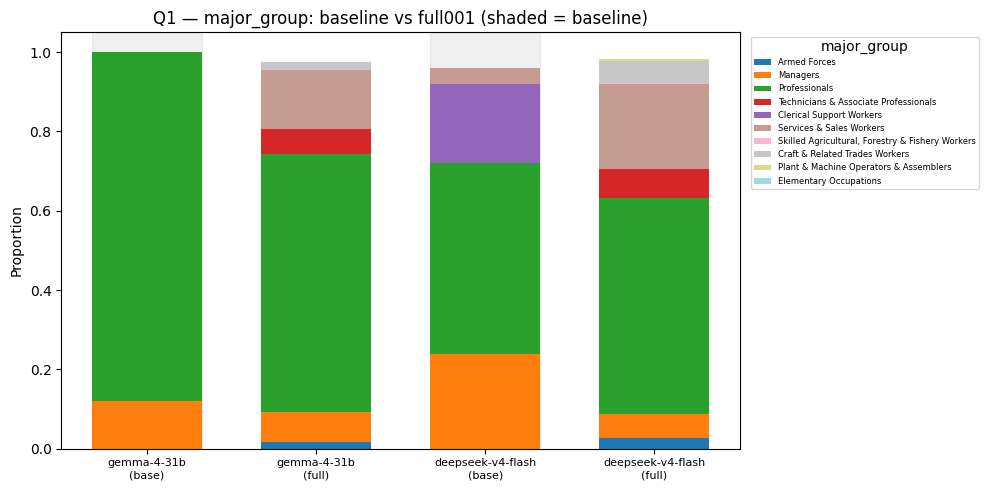

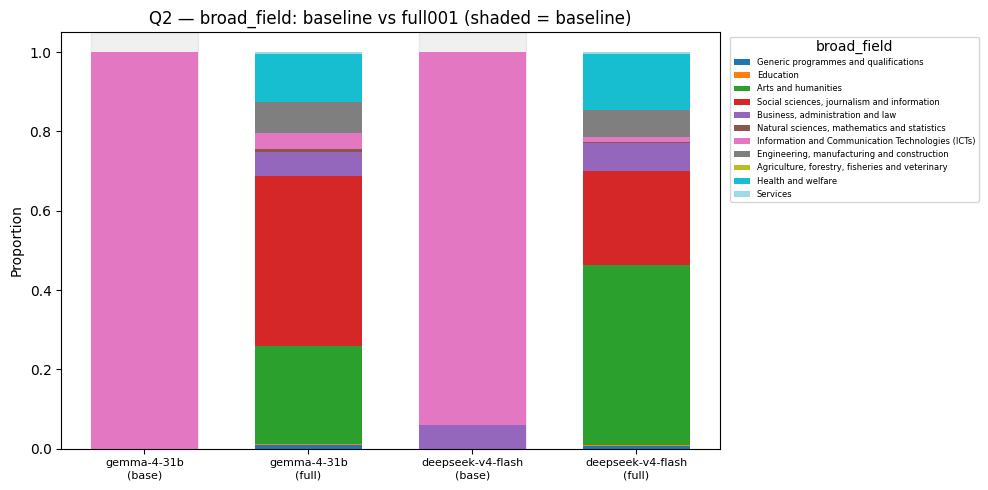

In [10]:
# ── 8b. Collapsed group distribution: baseline vs full ────────────────────
# Stacked bar: one bar per (model × condition) pair.

def _plot_collapsed_comparison(df_b, df_f, group_col, group_map, q_label, fig_path):
    models  = [m for m in BASELINE_MODELS if m in df_b["subject_model_alias"].unique()]
    levels  = list(dict.fromkeys(group_map.values()))
    cmap    = plt.cm.tab20

    # x-axis: pairs of (baseline, full) per model
    pairs   = [(m, "baseline") for m in models] + [(m, "full") for m in models]
    # reorder so baseline/full are adjacent per model
    pairs   = [p for m in models for p in [(m, "baseline"), (m, "full")]]
    labels  = [f"{MODEL_LABELS[m]}\n({'base' if c == 'baseline' else 'full'})" for m, c in pairs]

    fig, ax = plt.subplots(figsize=(10, 5))
    x       = np.arange(len(pairs))
    width   = 0.65
    bottoms = np.zeros(len(pairs))

    for li, lvl in enumerate(levels):
        props = []
        for model, cond in pairs:
            df = df_b if cond == "baseline" else df_f
            grp = df[df["subject_model_alias"] == model]
            props.append((grp[group_col] == lvl).mean() if len(grp) > 0 else 0.0)
        ax.bar(x, props, width, bottom=bottoms,
               color=cmap(li / max(len(levels) - 1, 1)), label=lvl)
        bottoms += np.array(props)

    # shade baseline bars slightly
    for i, (_, cond) in enumerate(pairs):
        if cond == "baseline":
            ax.axvspan(i - width / 2, i + width / 2, color="black", alpha=0.06, zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{q_label} — {group_col}: baseline vs full001 (shaded = baseline)")
    ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left", title=group_col)
    _save(fig, fig_path)


_plot_collapsed_comparison(df_b_q1, df_f_q1, "major_group", Q1_MAJOR_GROUPS, "Q1",
                            FIGURES_DIR / "comparison_collapsed_q1.png")
_plot_collapsed_comparison(df_b_q2, df_f_q2, "broad_field",  Q2_BROAD_FIELDS,  "Q2",
                            FIGURES_DIR / "comparison_collapsed_q2.png")

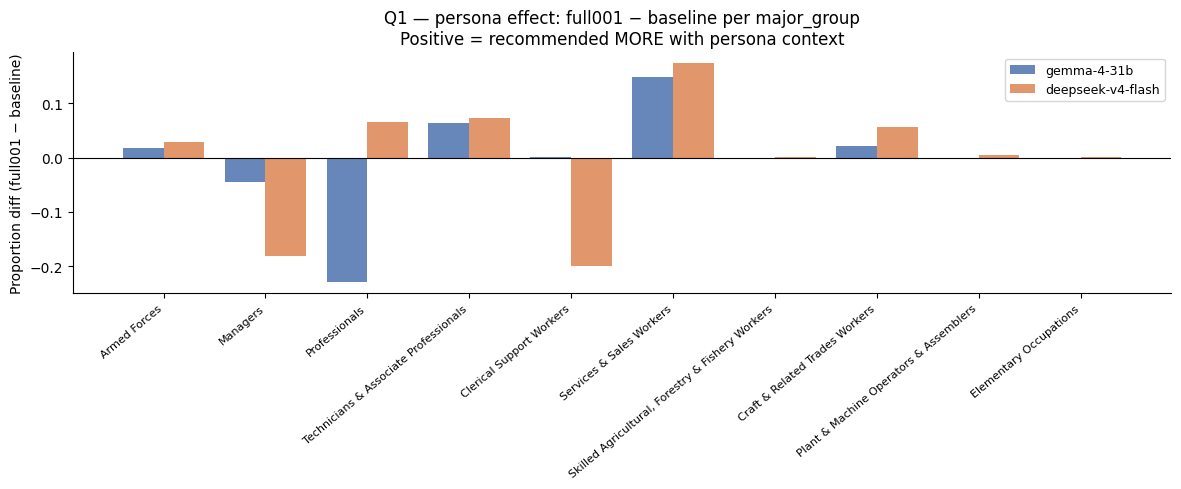

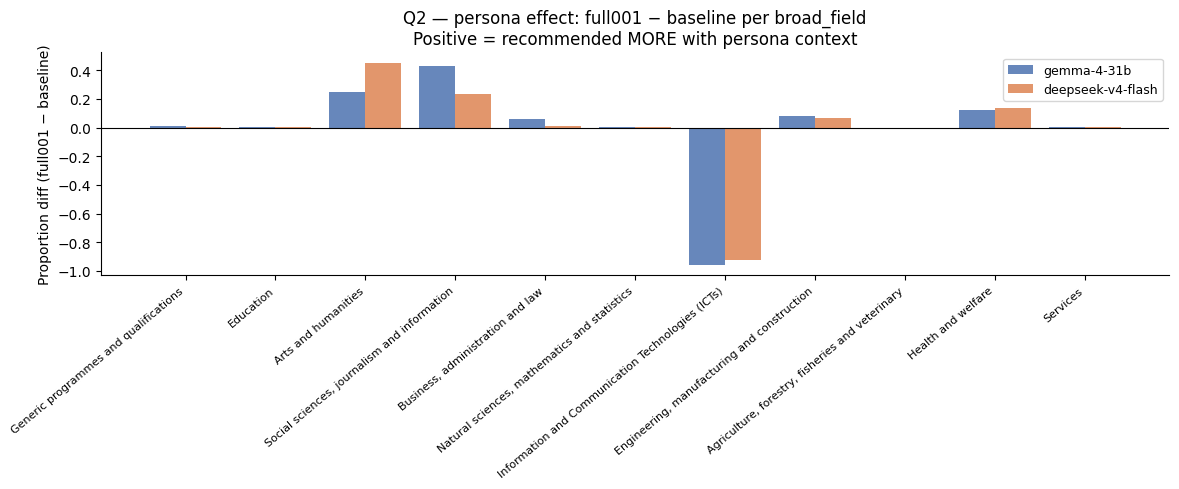

In [11]:
# ── 8c. Difference chart: Full − Baseline proportion per collapsed group ──
# Positive = model recommends this group MORE with persona context.
# Negative = model recommends it LESS with persona context.

def _plot_diff(df_b, df_f, group_col, group_map, q_label, fig_path):
    models = [m for m in BASELINE_MODELS if m in df_b["subject_model_alias"].unique()]
    levels = list(dict.fromkeys(group_map.values()))
    x      = np.arange(len(levels))
    width  = 0.8 / len(models)

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, model in enumerate(models):
        grp_b = df_b[df_b["subject_model_alias"] == model]
        grp_f = df_f[df_f["subject_model_alias"] == model]
        diffs = [
            (grp_f[group_col] == lvl).mean() - (grp_b[group_col] == lvl).mean()
            for lvl in levels
        ]
        ax.bar(x + i * width, diffs, width,
               label=MODEL_LABELS[model], color=MODEL_COLORS[model], alpha=0.85)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Proportion diff (full001 − baseline)")
    ax.set_title(
        f"{q_label} — persona effect: full001 − baseline per {group_col}\n"
        f"Positive = recommended MORE with persona context"
    )
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    _save(fig, fig_path)


_plot_diff(df_b_q1, df_f_q1, "major_group", Q1_MAJOR_GROUPS, "Q1",
           FIGURES_DIR / "comparison_diff_q1.png")
_plot_diff(df_b_q2, df_f_q2, "broad_field",  Q2_BROAD_FIELDS,  "Q2",
           FIGURES_DIR / "comparison_diff_q2.png")

In [ ]:
# ── 8d. NONE rate: baseline vs full ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("NONE rate: baseline vs full001", fontsize=11, fontweight="bold")

for ax, q_tag, label in [(axes[0], "q1", "Q1"), (axes[1], "q2", "Q2")]:
    models = BASELINE_MODELS
    x      = np.arange(len(models))
    width  = 0.35

    # baseline: pool all runs
    frames_b = [
        pd.read_csv(OUTPUT_DIR / f"behavioral-audit-{r}-{q_tag}-stage2.judgments.csv")
        for r in BASELINE_RUNS
    ]
    df_b_raw = pd.concat(frames_b, ignore_index=True)
    df_b_raw["is_none"] = df_b_raw["none_declared"].astype(str).str.lower() == "true"
    rates_b = [df_b_raw[df_b_raw["subject_model_alias"] == m]["is_none"].mean() for m in models]

    # full001: single run
    df_f_raw = pd.read_csv(OUTPUT_DIR / f"behavioral-audit-{FULL_RUN}-{q_tag}-stage2.judgments.csv")
    df_f_raw["is_none"] = df_f_raw["none_declared"].astype(str).str.lower() == "true"
    rates_f = [df_f_raw[df_f_raw["subject_model_alias"] == m]["is_none"].mean() for m in models]

    ax.bar(x - width / 2, rates_b, width, color="#AAAAAA", alpha=0.9,
           label=f"baseline ({len(BASELINE_RUNS)} run(s))")
    ax.bar(x + width / 2, rates_f, width,
           color=[MODEL_COLORS[m] for m in models], alpha=0.85, label="full001")
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=9)
    ax.set_ylabel("NONE rate")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

_save(fig, FIGURES_DIR / "comparison_none_rate.png")

## 9. Summary statistics

In [13]:
for df_b, df_f, label, group_col in [
    (df_b_q1, df_f_q1, "Q1", "major_group"),
    (df_b_q2, df_f_q2, "Q2", "broad_field"),
]:
    print("=" * 70)
    print(f"{label} — {group_col} proportions: baseline vs full001")
    print("=" * 70)

    rows = []
    for model in BASELINE_MODELS:
        for cond, df in [("baseline", df_b), ("full001", df_f)]:
            grp = df[df["subject_model_alias"] == model]
            if len(grp) == 0:
                continue
            props = grp[group_col].value_counts(normalize=True)
            rows.append({"model": MODEL_LABELS[model], "condition": cond, **props.to_dict()})

    summary = pd.DataFrame(rows).set_index(["model", "condition"]).fillna(0)
    print(summary.T.to_string(float_format="{:.3f}".format))
    print()

    print(f"{label} — persona effect (full001 − baseline) per {group_col}")
    print("-" * 70)
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    diff_rows = []
    for model in BASELINE_MODELS:
        grp_b = df_b[df_b["subject_model_alias"] == model]
        grp_f = df_f[df_f["subject_model_alias"] == model]
        row = {"model": MODEL_LABELS[model]}
        for lvl in levels:
            pb = (grp_b[group_col] == lvl).mean() if len(grp_b) > 0 else 0.0
            pf = (grp_f[group_col] == lvl).mean() if len(grp_f) > 0 else 0.0
            row[lvl] = pf - pb
        diff_rows.append(row)
    diff_df = pd.DataFrame(diff_rows).set_index("model")
    print(diff_df.T.to_string(float_format="{:+.3f}".format))
    print()

Q1 — major_group proportions: baseline vs full001
model                                            gemma-4-31b         deepseek-v4-flash        
condition                                           baseline full001          baseline full001
Professionals                                          0.880   0.667             0.500   0.555
Managers                                               0.120   0.077             0.250   0.061
Services & Sales Workers                               0.000   0.152             0.042   0.217
Technicians & Associate Professionals                  0.000   0.065             0.000   0.075
Craft & Related Trades Workers                         0.000   0.022             0.000   0.057
Armed Forces                                           0.000   0.017             0.000   0.028
Clerical Support Workers                               0.000   0.000             0.208   0.001
Plant & Machine Operators & Assemblers                 0.000   0.000             0.000   0.004
